In [269]:
import numpy as np
import random
import math

In [270]:
zgrid=np.arange(0.1,8.1,0.1)

In [286]:
import numpy as np

def f_LAF(z):
    z = np.asarray(z, dtype=float)

    f = np.empty_like(z)

    m1 = z < 1.2
    m2 = (z >= 1.2) & (z < 4.7)
    m3 = z >= 4.7

    f[m1] = ((1.0 + z[m1]) / 2.2)**0.2
    f[m2] = ((1.0 + z[m2]) / 2.2)**2.7
    f[m3] = ((5.7/2.2)**2.7) * (((1.0 + z[m3]) / 5.7)**4.5)

    return 500.0 * f

In [287]:
def f_DLA(z):
    z = np.asarray(z, dtype=float)

    f = np.empty_like(z)

    m1 = z < 2
    m2 = z >= 2

    f[m1] = ((1+z[m1])/3)
    f[m2] = ((1+z[m2])/3)**2
    return 1.1*f

In [305]:
def g_LAF(size, N_l=1e12, N_u=1e23, beta=1.7, Nc=1e21, ngrid=20000):
    x = np.linspace(np.log10(N_l), np.log10(N_u), ngrid)
    N = 10.0**x
    pdf_x = (N**(-beta)) * np.exp(-N / Nc) * (np.log(10.0) * N)
    dx = x[1] - x[0]
    cdf = np.cumsum(pdf_x) * dx
    cdf /= cdf[-1]
    u = np.random.rand(size)
    x_samp = np.interp(u, cdf, x)
    return 10.0**x_samp

In [304]:
def g_DLA(size,N_l=1e12, N_u=1e23,beta=0.9,Nc=1e21):
    x = np.linspace(np.log10(N_l), np.log10(N_u), 10000)
    N = 10**x
    pdf = (N**(-beta)) * np.exp(-N/Nc) * (np.log(10) * N)
    dx = x[1] - x[0]
    cdf = np.cumsum(pdf)*dx
    cdf = cdf / cdf[-1]
    u = np.random.rand(size)
    x_sample = np.interp(u, cdf, x)
    return 10**x_sample
    

In [275]:
f = np.array([4.164e-1, 7.914e-2, 2.901e-2, 1.395e-2, 7.803e-3, 4.817e-3,  3.185e-3,  2.217e-3, 1.606e-3])
gamma = np.array([6.265e8,  1.897e8, 8.127e7, 4.204e7,  2.450e7,  1.551e7, 1.043e7, 7.344e6, 5.366e6 ])
lam0= np.array([1215.67e-10,1025.72e-10,972.537e-10,949.743e-10,937.803e-10,930.748e-10,926.226e-10,923.150e-10,920.963e-10])
nu0=np.array([3e8/x for x in lam0])

In [276]:
from sedpy.observate import getSED, load_filters

fil=['cfht_u','hsc_g','sc_IB427','sc_IB464','subaru_suprimecam_ia484','sc_IB505','subaru_suprimecam_ia527','hsc_r','sc_IB574','subaru_suprimecam_ia624','subaru_suprimecam_ia679','hsc_i','sc_IB709','subaru_suprimecam_ia738',
    'subaru_suprimecam_ia767','sc_IB827','sc_NB711','sc_NB816','hsc_z','hsc_y','vista_vircam_Y','vista_vircam_J','vista_vircam_H','vista_vircam_Ks','irac_ch1','irac_ch2']

filters = load_filters(fil)

In [277]:
nu=[]
lam=[]
for k in filters:
    nu.append(3*10**8/(np.mean(k.wavelength*1e-10)))
    lam.append(np.mean(k.wavelength*1e-10))
nu=np.array(nu)
lam=np.array(lam)

In [279]:
def H(a,x):
    r=np.exp(-x**2)
    r_sin=(1-np.exp(-2*x**2))/2
    term1=((4*x**2)+3)*((x**2)+1)*r**2
    term2=(1/x**2)*((2*x**2)+3)*r_sin
    k=(1/(2*x**2))*(term1-term2)
    h=r-(2*a/np.sqrt(np.pi))*k
    return h

In [280]:
b=28e3
c=3e8
qe=1.6e-19
me=9.1e-31
k=8.99e9
delv = nu0 * b / c  
cons = (np.sqrt(np.pi) * k * qe**2 * f) / (me * c * delv)
a=gamma / (4.0 * np.pi * delv)
def sigi(zabs):
    zabs = np.asarray(zabs, dtype=np.float64)  
    nabs = zabs.size
    x = (nu[None, :, None] * (1.0 + zabs[:, None, None]) - nu0[None, None, :]) / delv[None, None, :]
    h = H(a[None, None, :], x)
    return np.sum(cons[None, None, :] * h, axis=2)


In [281]:
sigLL=6.3*10**-22
nuLL=3e8/912e-10
def siglc(z):
    nu_rest = nu[None, :] * (1.0 + z[..., None])
    out = sigLL * (nuLL / nu_rest) **3
    return out

In [309]:
# Precompute once:
z_tab = np.linspace(0.0, 8, 50000)
laf = f_LAF(z_tab)
dla = f_DLA(z_tab)
dz  = np.diff(z_tab)

L_laf = np.concatenate([[0.0], np.cumsum(0.5*(laf[1:]+laf[:-1])*dz)])
L_dla = np.concatenate([[0.0], np.cumsum(0.5*(dla[1:]+dla[:-1])*dz)])

def sample_absorbers(zs):
    m = np.searchsorted(z_tab, zs)
    Lam_laf = L_laf[m]
    Lam_dla = L_dla[m]

    n_laf = rng.poisson(Lam_laf)
    n_dla = rng.poisson(Lam_dla)

    # redshifts
    u_laf = rng.random(n_laf) * Lam_laf
    u_dla = rng.random(n_dla) * Lam_dla
    z_laf = np.interp(u_laf, L_laf[:m+1], z_tab[:m+1])
    z_dla = np.interp(u_dla, L_dla[:m+1], z_tab[:m+1])

    # NHI draws (use cached inverse-CDF samplers)
    N_laf = g_LAF(size=n_laf)
    N_dla = g_DLA(size=n_dla)

    zabs = np.concatenate([z_laf, z_dla])
    nhi  = np.concatenate([N_laf, N_dla])
    return zabs, nhi

In [387]:
taus=np.load('taus.npy')

In [383]:
taus1=np.empty((9,1000,26))

In [385]:
zgrid=np.arange(6,8.25,0.25)
for i,z in enumerate(zgrid):
    for k in range(1000):
        if k%500==0:
            print(z,k)
        zabs, nhi = sample_absorbers(z)
        sigma = siglc(zabs) + sigi(zabs)   
        tau = (nhi[:,None]*sigma).sum(axis=0)
        taus[i,k,:]=tau

6.0 0
6.0 500
6.25 0
6.25 500
6.5 0
6.5 500
6.75 0
6.75 500
7.0 0
7.0 500
7.25 0
7.25 500
7.5 0
7.5 500
7.75 0
7.75 500
8.0 0
8.0 500


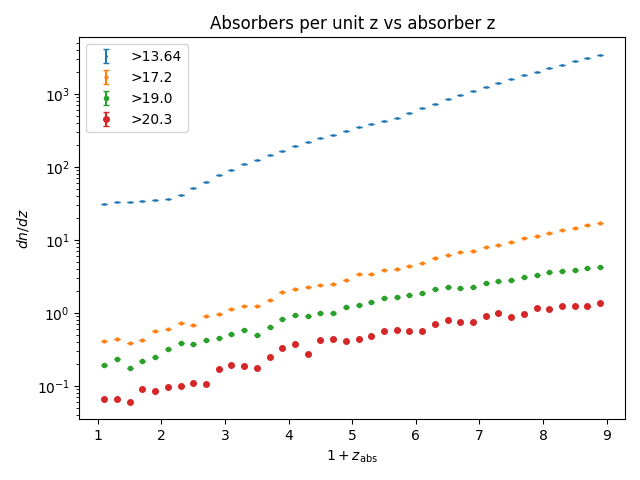

In [338]:
import numpy as np
import matplotlib.pyplot as plt

# 1) generate a big absorber catalog from many sightlines
def simulate_catalog(zs, Nsight, rng):
    z_all = []
    N_all = []
    for _ in range(Nsight):
        zabs, nhi = sample_absorbers(zs)
        z_all.append(zabs)
        N_all.append(nhi)
    z_all = np.concatenate(z_all) if len(z_all) else np.array([])
    N_all = np.concatenate(N_all) if len(N_all) else np.array([])
    return z_all, N_all

rng = np.random.default_rng(0)

zs_max  = 8.0
Nsight  = 1000 # increase until curves are smooth
zabs, nhi = simulate_catalog(zs_max, Nsight, rng)

logN = np.log10(nhi)

# 2) bin in absorber redshift, compute dn/dz for each threshold
z_bins = np.linspace(0.0, zs_max, 41)              # choose binning to match the paper visually
dz     = np.diff(z_bins)
z_ctr  = 0.5 * (z_bins[:-1] + z_bins[1:])

thresholds = [13.64, 17.2, 19.0, 20.3]

plt.figure()
for i,t in enumerate(thresholds):
    m = logN > t
    counts, _ = np.histogram(zabs[m], bins=z_bins)
    dn_dz = counts / (Nsight * dz)

    # Poisson error bars (same logic as observational errorbars in these incidence plots)
    err = np.sqrt(np.maximum(counts, 1)) / (Nsight * dz)

    plt.errorbar(1.0 + z_ctr, dn_dz, yerr=0, fmt='o', markersize=int(1+i), capsize=2, label=f'>{t}')

plt.yscale('log')
plt.xlabel(r'$1+z_{\rm abs}$')
plt.title('Absorbers per unit z vs absorber z')
plt.ylabel(r'$dn/dz$')
plt.legend()
plt.tight_layout()
plt.show()

In [334]:
len(zabs)

87218

In [154]:
taus=np.empty((len(zgrid),1000,26))
for i,zs in enumerate(zgrid):
    for k in range(1000):
        z = 0.0
        nhi=[]
        zabs=[]
        while z < zs:
            rate = f_LAF(z) + f_DLA(z)          
            dz = -np.log(np.random.rand())/rate
            z_next = z + dz
            if z_next >= zs:
                break
            zabs.append(z_next)
            pL = f_LAF(z_next) / (f_LAF(z_next) + f_DLA(z_next))
            if np.random.rand() < pL:
                NHI = g_LAF()            
            else:
                NHI = g_DLA()
            nhi.append(NHI)
            z = z_next
        tau=np.zeros(26)
        for j in range(len(nhi)):
            t=nhi[j]*(np.add(siglc(zabs[j],nu),sigi([zabs[j]])))
            tau=np.add(tau,t)
        taus[i,k,:]=tau   

KeyboardInterrupt: 